#### **Data Processing**

In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
all_results_healthcare_clean = pd.read_csv('../healthcare_with_combi.csv').set_index('date').drop(columns='Unnamed: 0')
all_results_tech_clean = pd.read_csv('../tech_with_combi.csv').set_index('date').drop(columns='Unnamed: 0')
all_results_tech_clean

,rolling_alpha_5f,lasso,ridge,xgboost,lgbm,rf,pca,lstm,benchmark_alpha,simple_avg,err_weighted
date,,,,,,,,,,,
2019-03-29,-0.064261,0.011322,0.005189,0.016915,0.013942,0.012832,0.012908,0.013421,0.000000,0.012361,0.012361
2019-03-29,-0.029964,0.014797,0.008808,0.018278,0.013942,0.014267,0.017173,0.017850,0.000000,0.015017,0.014570
2019-03-29,-0.021149,-0.001822,-0.007796,-0.009167,-0.002699,-0.011748,-0.001378,-0.000003,0.000000,-0.004945,-0.007474
2019-03-29,-0.019178,-0.001233,-0.009139,-0.008551,-0.002699,-0.009513,-0.000625,0.001698,0.000000,-0.004295,-0.006738
2019-03-29,-0.017032,-0.000352,-0.003391,-0.008318,-0.002699,-0.006186,-0.000841,-0.002480,0.000000,-0.003467,-0.004750
...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28,0.045010,0.012207,0.014545,0.020629,0.014624,0.025652,0.014393,0.017015,0.002931,0.017009,0.018710
2024-07-31,0.010018,0.002183,-0.002810,0.005508,0.005679,0.006577,0.003015,-0.001950,0.004697,0.002600,0.005003
2024-07-31,0.010697,0.002353,-0.002306,0.005810,0.005706,0.006999,0.003034,0.001361,0.004697,0.003280,0.005212


In [ ]:
# Generation of Error Metrics
def mean_absolute_scaled_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    naive_mae = np.mean(np.abs(y_true[1:] - y_true[:-1]))
    mae = mean_absolute_error(y_true, y_pred)
    mase = mae / naive_mae if naive_mae != 0 else np.nan

    return mase 

def metrics_generator(df, metric, outcome_var, relevant_cols):
    if metric == 'MASE':
        final_df = df.groupby(df.index).apply(
            lambda group: pd.Series({
                col: mean_absolute_scaled_error(group[outcome_var], group[col]) for col in relevant_cols
            })
        )
    elif metric == 'MAE':
        final_df = df.groupby(df.index).apply(
            lambda group: pd.Series({
                col: mean_absolute_error(group[outcome_var], group[col]) for col in relevant_cols
            })
        )
    elif metric == 'R2':
        final_df = df.groupby(df.index).apply(
            lambda group: pd.Series({
                col: max(r2_score(group[outcome_var], group[col]), -2) for col in relevant_cols
            })
        )
    elif metric == 'MSE':
        final_df = df.groupby(df.index).apply(
            lambda group: pd.Series({
                col: mean_squared_error(group[outcome_var], group[col]) for col in relevant_cols
            })
        )
    else:
        final_df = df.groupby(df.index).apply(
            lambda group: pd.Series({
                col: np.sqrt(mean_squared_error(group[outcome_var], group[col])) for col in relevant_cols
            })
        )
    return final_df

models = ['ridge', 'rf', 'xgboost', 'pca', 'lasso', 'lgbm', 'lstm', 'benchmark_alpha','simple_avg','err_weighted']
    
rmse_healthcare = metrics_generator(all_results_healthcare_clean, metric = "RMSE", outcome_var="rolling_alpha_5f", relevant_cols = models)
rmse_tech = metrics_generator(all_results_tech_clean, metric = "RMSE", outcome_var="rolling_alpha_5f", relevant_cols = models)

#### **Plots**

Plot 1: Metrics Plot by Time

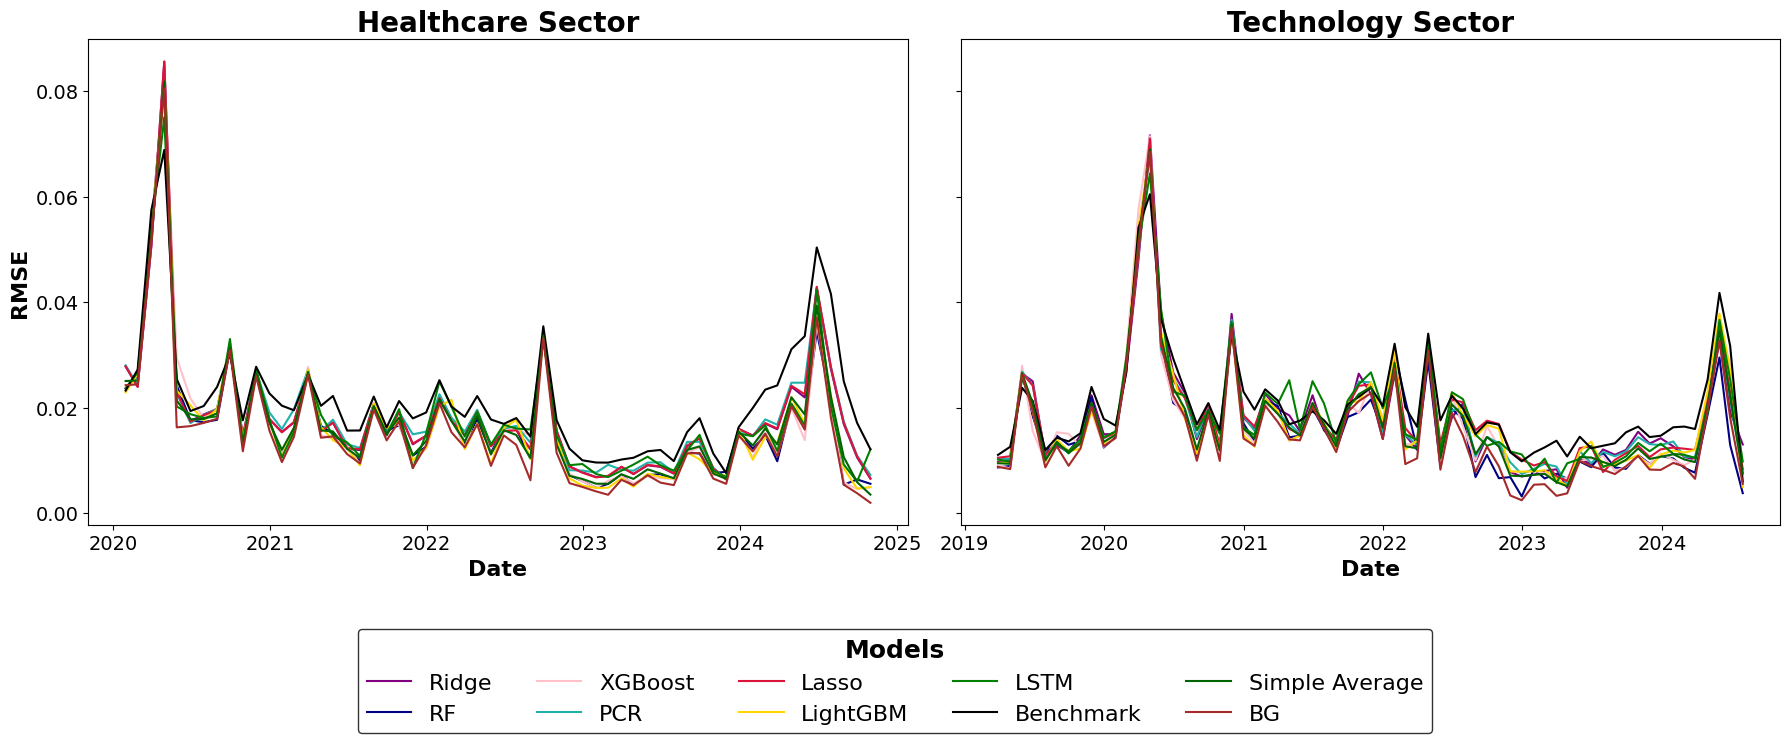

In [ ]:
# Single Plot
import pandas as pd
import matplotlib.pyplot as plt
label_mapping = {'ridge': 'Ridge', 'xgboost': 'XGBoost', 'rf': 'RF', 'pca': 'PCR', 'lasso': 'Lasso',
                 'lgbm':'LightGBM', 'lstm':'LSTM','benchmark_alpha':'Benchmark',
                 'simple_avg':'Simple Average', 'err_weighted':'BG'}
color_list = {'Ridge': 'purple', 'XGBoost': 'pink', 'PCR': 'lightseagreen', 'RF': 'navy', 'Lasso':'crimson', 
              'LightGBM':'gold', 'LSTM':'green', 'Benchmark':'black',
              'Simple Average':'darkgreen', 'BG':'brown'}

# Load your data (assuming it's already in a DataFrame named df)
rmse_healthcare.index = pd.to_datetime(rmse_healthcare.index)  # Ensure index is datetime
rmse_tech.index = pd.to_datetime(rmse_tech.index)  # Ensure index is datetime

# Create a 1x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(18, 6),sharey=True)

# First plot (Healthcare RMSE)
for column in rmse_healthcare.columns:
    axes[0].plot(rmse_healthcare.index, rmse_healthcare[column], label=label_mapping[column], color=color_list[label_mapping[column]])

# Formatting for the first plot
axes[0].set_xlabel("Date", fontsize=16, fontweight='bold')
axes[0].set_ylabel("RMSE", fontsize=16, fontweight='bold')
axes[0].set_title("Healthcare Sector", fontweight='bold',fontsize = 20)
axes[0].grid(False)
axes[0].tick_params(axis='both', labelsize=14)

# Second plot (Tech RMSE)
for column in rmse_tech.columns:
    axes[1].plot(rmse_tech.index, rmse_tech[column], label=label_mapping[column], color=color_list[label_mapping[column]])

# Formatting for the second plot
axes[1].set_xlabel("Date", fontsize=16, fontweight='bold')
axes[1].set_title("Technology Sector", fontweight='bold',fontsize = 20)
handles, labels = plt.gca().get_legend_handles_labels()
unique_legend = dict(zip(labels, handles))  # Remove duplicates by using a dictionary

# Add the unique legend to the figure
legend = fig.legend(unique_legend.values(), unique_legend.keys(),  
           bbox_to_anchor=(0.5, -0.25), loc='lower center', ncol=5, title = "Models",
           fontsize = 16, title_fontsize = 18)
legend.get_title().set_fontweight('bold')
legend.set_visible(True)
legend.get_frame().set_edgecolor('black')
axes[1].grid(False)
axes[1].tick_params(axis='both', labelsize=14)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

Plot 3: Cumulative Alpha Over Time

In [ ]:
def plot_difference(df, outcome_var):
    df_to_plot = df.copy()
    df_to_plot.index = pd.to_datetime(df_to_plot.index)
    df_to_plot = df_to_plot.sort_index()
    df_to_plot = df_to_plot.groupby(df_to_plot.index).mean()  # Take mean for duplicated dates

    model_cols = [col for col in df_to_plot.columns if col != outcome_var]
    df_to_plot[outcome_var] = (df_to_plot[outcome_var] - df_to_plot[outcome_var].mean()) / df_to_plot[outcome_var].std()
    # return(df_to_plot)
    # Cumulative actual alpha
    df_to_plot["benchmark_alpha"] = (df_to_plot["benchmark_alpha"] - df_to_plot["benchmark_alpha"].mean()) / df_to_plot["benchmark_alpha"].std()
    df_to_plot['cumulative_action_based_benchmark_alpha'] = (df_to_plot["benchmark_alpha"] * df_to_plot[outcome_var]).cumsum()

    # Compute cumulative action-based alpha for all models and create diff columns
    for col in model_cols:
        if col == 'benchmark_alpha':
            df_to_plot[f'cumulative_action_based_{col}_diff'] = 0
        else:
            df_to_plot[col] = (df_to_plot[col] - df_to_plot[col].mean()) / df_to_plot[col].std()
            df_to_plot[f'cumulative_action_based_{col}'] = ((df_to_plot[col] * df_to_plot[outcome_var]).cumsum())
            df_to_plot[f'cumulative_action_based_{col}_diff'] = df_to_plot[f'cumulative_action_based_{col}'] - df_to_plot['cumulative_action_based_benchmark_alpha']

    # Now we rank the models based on the _diff (higher _diff = higher rank)
    rank_df = df_to_plot[[f'cumulative_action_based_{col}_diff' for col in model_cols]]

    # Rank based on the _diff, higher values get higher ranks
    ranked_df = rank_df.apply(lambda row: row.rank(ascending=False), axis=1)  # Rank within each date row
    # return(ranked_df)
    # Rename the columns to reflect the model names
    ranked_df.columns = model_cols  # map labels like 'ridge' to 'Ridge'
    ranked_df.index = pd.to_datetime(ranked_df.index)
    # return(ranked_df)
    
    # Combine both DataFrames (first and last month data)
    selected_months_df = ranked_df[ranked_df.index.month.isin([1, 7])]

    # Add the last month of each year
    list_of_dates = df_to_plot.index
    dates = pd.to_datetime(list_of_dates)
    df = pd.DataFrame(dates, columns=['date'])
    df['year'] = df['date'].apply(lambda x: x.year)
    max_dates = df.groupby('year')['date'].transform('max')
    final_date = pd.Series(max_dates).sort_values().unique()[-1]
    last_month = ranked_df[ranked_df.index == final_date]

    # Combine the two selections
    combined_df = pd.concat([selected_months_df,last_month])
    return(combined_df)

# Plotting Healthcare and Tech Together

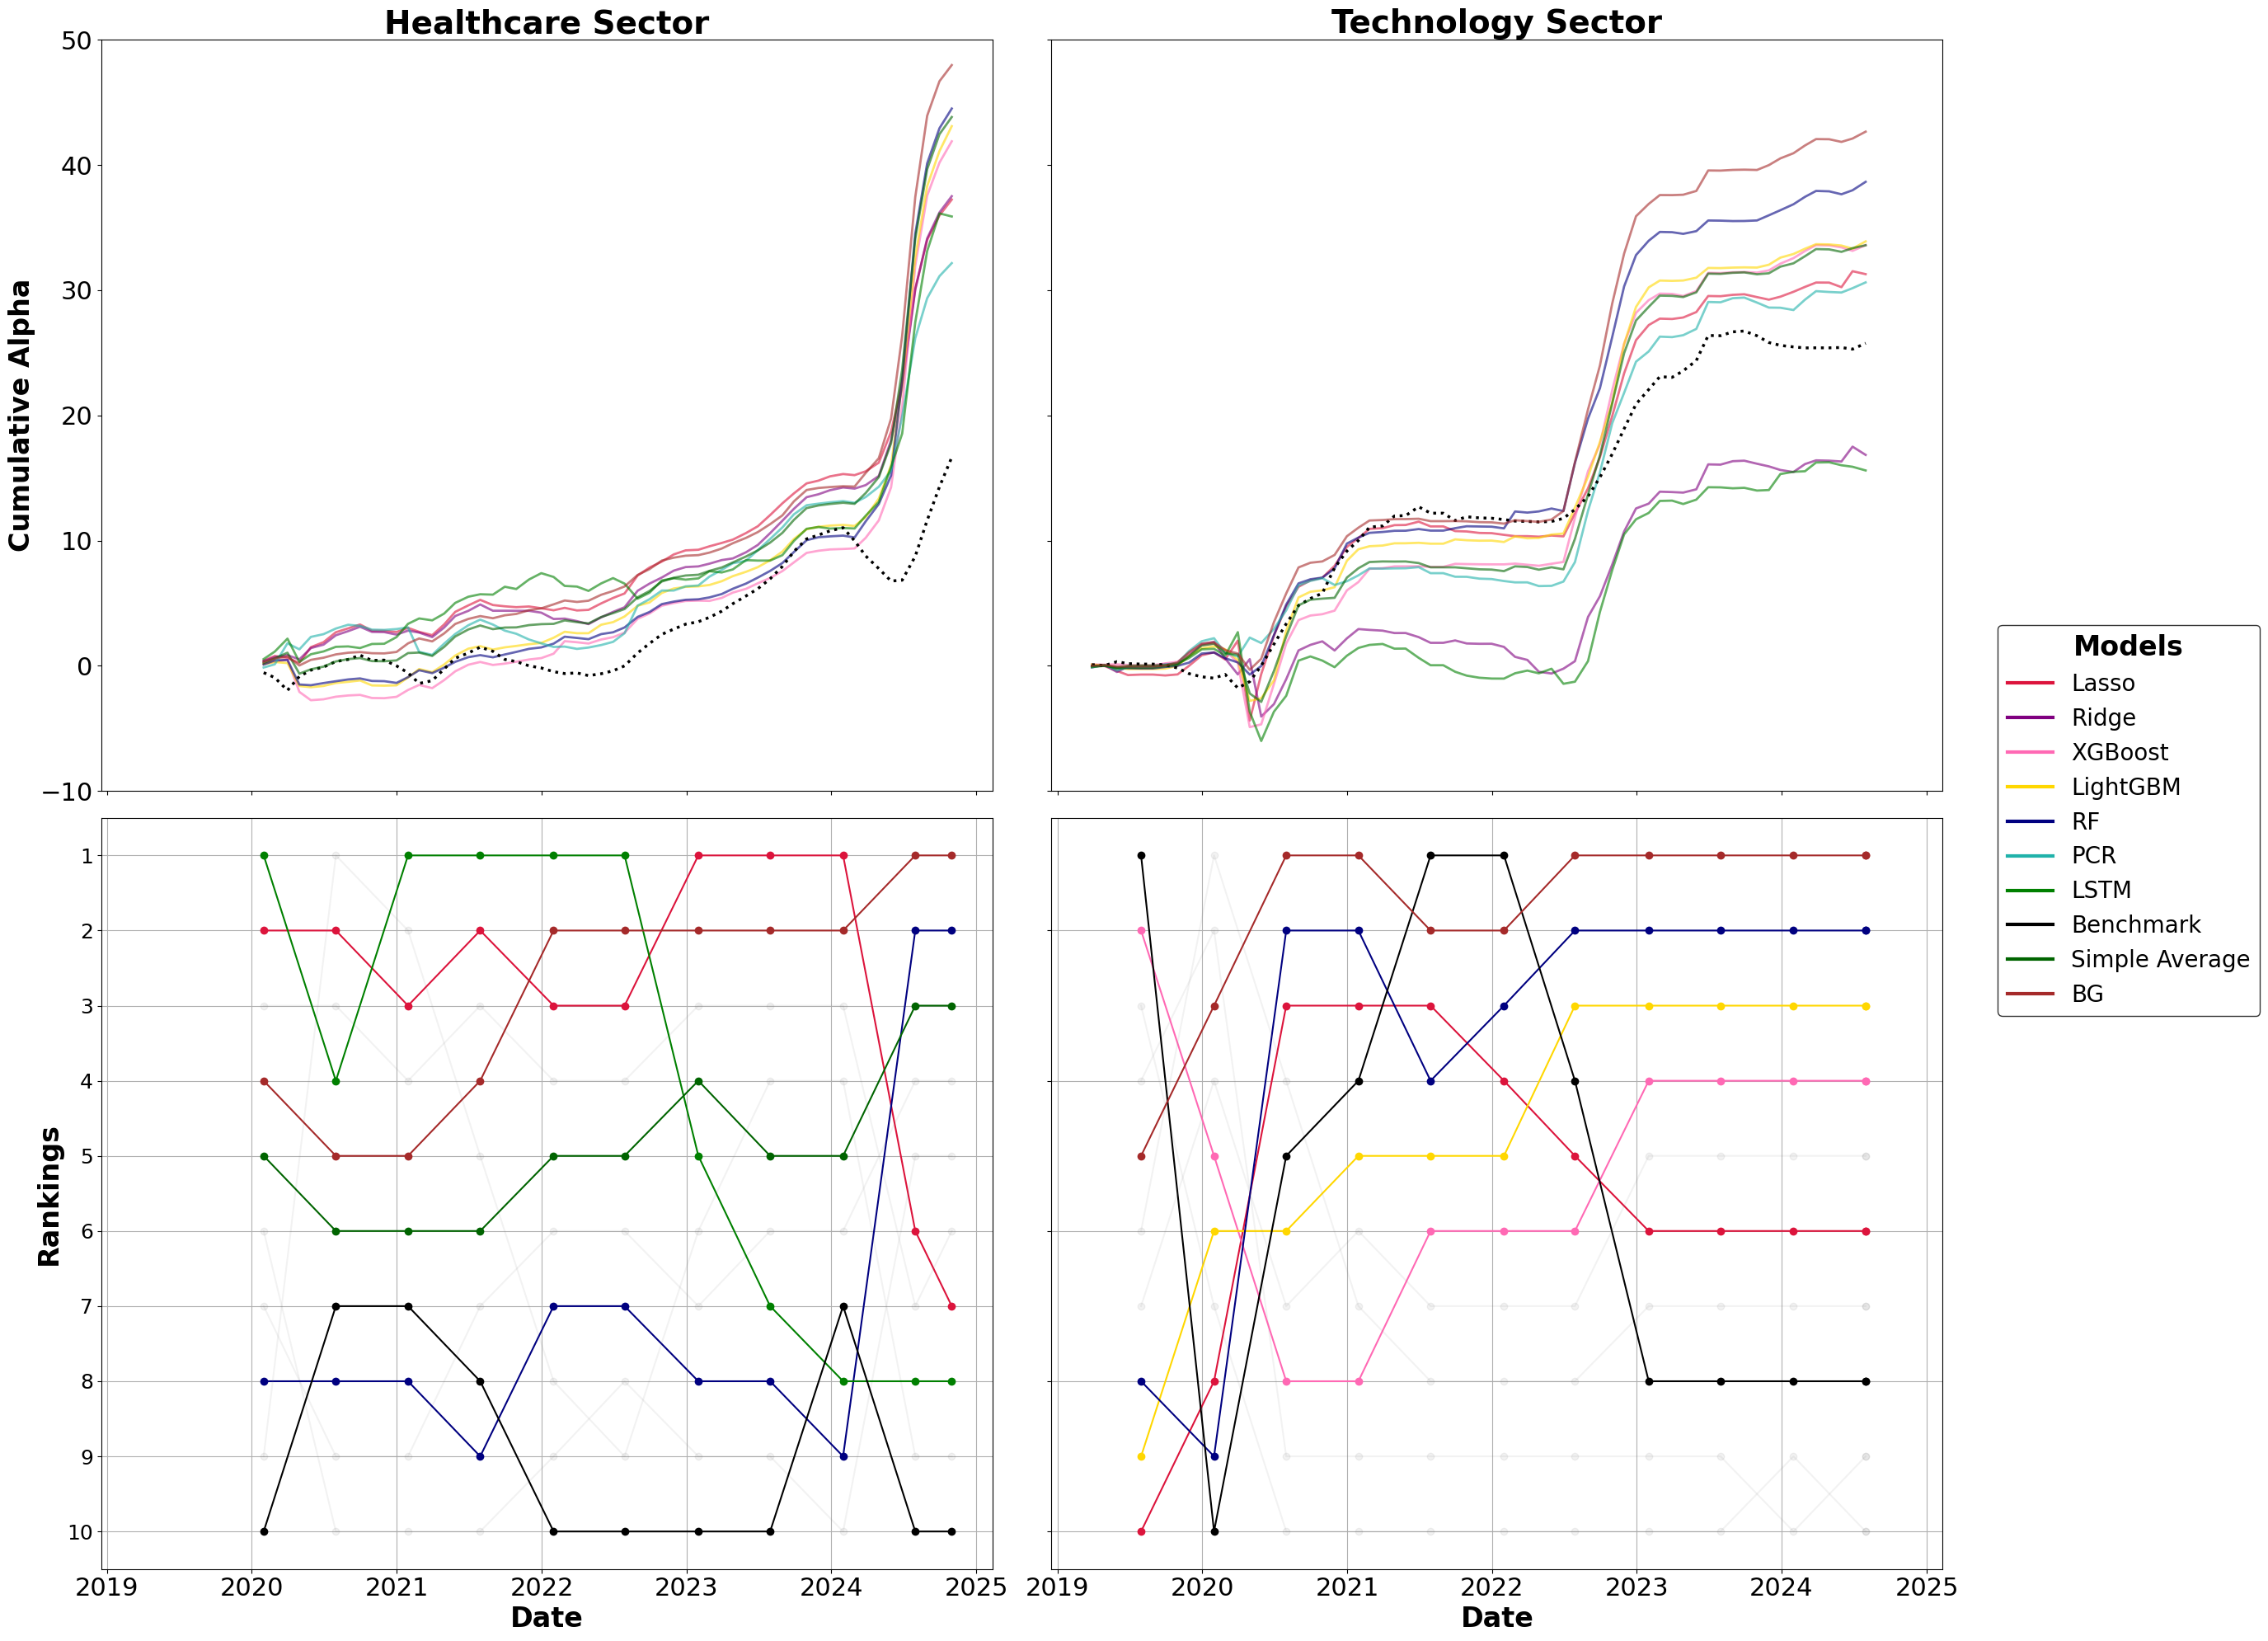

In [ ]:
def plot_combined_subplot(df1, df2, plot_difference_fn, outcome_var, color_list1, color_list2):
    label_mapping = {'ridge': 'Ridge', 'xgboost': 'XGBoost', 'rf': 'RF', 'pca': 'PCR', 'lasso': 'Lasso', 
                     'lgbm':'LightGBM', 'lstm':'LSTM','benchmark_alpha':'Benchmark',
                     'simple_avg':'Simple Average', 'err_weighted':'BG'}
    
    color_list = {'Ridge': 'purple', 'XGBoost': 'hotpink', 'PCR': 'lightseagreen', 'RF': 'navy', 'Lasso':'crimson', 
                  'LightGBM':'gold', 'LSTM':'green', 'Benchmark':'black',
                  'Simple Average':'darkgreen', 'BG':'brown'}
    
    ranking_df1 = plot_difference_fn(df1, outcome_var=outcome_var)
    ranking_df2 = plot_difference_fn(df2, outcome_var=outcome_var)

    # Create a 2x2 subplot layout
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(24, 20), sharex=True)

    # First dataset (Healthcare) - Cumulative Alpha
    axis1 = axes[0, 0]
    axis2 = axes[1, 0]
    custom_legend_handles = []

    df1.index = pd.to_datetime(df1.index)
    df1 = df1.sort_index().groupby(df1.index).mean()
    model_cols = [col for col in df1.columns if col != outcome_var]
    df1[outcome_var] = (df1[outcome_var] - df1[outcome_var].mean()) / df1[outcome_var].std()

    for col in model_cols:
        df1[col] = (df1[col] - df1[col].mean()) / df1[col].std()
        df1[f'cumulative_action_based_{col}'] = (df1[col] * df1[outcome_var]).cumsum()
        label = label_mapping.get(col, col)
        color = color_list.get(label, 'black')
        
        if col == "benchmark_alpha":
            axis1.plot(df1.index, df1[f'cumulative_action_based_{col}'], label=label, color=color, linewidth=2.5, linestyle='dotted')
        else:
            axis1.plot(df1.index, df1[f'cumulative_action_based_{col}'], label=label, color=color, linewidth=2, alpha=0.6)

        if col not in [lbl for _, lbl in custom_legend_handles]:
            custom_legend_handles.append((plt.Line2D([0], [0], color=color, lw=3), label_mapping[col]))

    axis1.set_ylabel('Cumulative Alpha', fontsize=24, fontweight='bold')
    axis1.grid(False)
    axis1.set_ylim(-10, 50)
    axis1.tick_params(axis='y', labelsize=22)
    for column in ranking_df1.columns:
        color = color_list1.get(label_mapping[column], 'black')
        alpha = 0.1 if color == "grey" else 1
        axis2.plot(ranking_df1.index, ranking_df1[column], label=label_mapping[column], marker='o', color=color, alpha=alpha)

    axis1.set_title("Healthcare Sector", fontweight='bold',fontsize = 28)
    
    axis2.set_ylim(0.5, 10.5)
    axis2.set_xlabel('Date', fontsize=24, fontweight='bold')
    axis2.tick_params(axis='both', labelsize=22)
    axis2.set_ylabel('Rankings', fontsize=24, fontweight='bold')
    axis2.invert_yaxis()
    axis2.set_yticks(range(1, 11))
    axis2.set_yticklabels([str(i) for i in range(1, 11)], fontsize=18)
    axis2.grid(True)

    # Second dataset (Tech) - Cumulative Alpha
    axis3 = axes[0, 1]
    axis4 = axes[1, 1]

    df2.index = pd.to_datetime(df2.index)
    df2 = df2.sort_index().groupby(df2.index).mean()
    df2[outcome_var] = (df2[outcome_var] - df2[outcome_var].mean()) / df2[outcome_var].std()

    for col in model_cols:
        df2[col] = (df2[col] - df2[col].mean()) / df2[col].std()
        df2[f'cumulative_action_based_{col}'] = (df2[col] * df2[outcome_var]).cumsum()
        label = label_mapping.get(col, col)
        color = color_list.get(label, 'black')

        if col == "benchmark_alpha":
            axis3.plot(df2.index, df2[f'cumulative_action_based_{col}'], label=label, color=color, linewidth=2.5, linestyle='dotted')
        else:
            axis3.plot(df2.index, df2[f'cumulative_action_based_{col}'], label=label, color=color, linewidth=2, alpha=0.6)
    axis3.set_ylim(-10, 50)
    axis3.set_yticklabels([])
    axis3.set_title("Technology Sector", fontweight='bold',fontsize = 28)
    axis3.grid(False)

    for column in ranking_df2.columns:
        color = color_list2.get(label_mapping[column], 'black')
        alpha = 0.1 if color == "grey" else 1
        axis4.plot(ranking_df2.index, ranking_df2[column], label=label_mapping[column], marker='o', color=color, alpha=alpha)

    axis4.set_ylim(0.5, 10.5)
    axis4.set_xlabel('Date', fontsize=24, fontweight='bold')
    axis4.tick_params(axis='x', labelsize=22)
    axis4.invert_yaxis()
    axis4.grid(True)
    axis4.set_yticklabels([])
    
    # Common legend
    legend = fig.legend(fontsize=20, loc='center right', bbox_to_anchor=(1.15, 0.5),
                        handles=[handle[0] for handle in custom_legend_handles],
                        labels=[handle[1] for handle in custom_legend_handles],
                        title="Models", title_fontsize=24)
    legend.get_title().set_fontweight('bold')
    legend.get_frame().set_edgecolor('black')

    plt.tight_layout()
    plt.show()

# Define color lists
color_list_healthcare = {'Ridge': 'grey', 'XGBoost': 'grey', 'PCR': 'grey', 'RF': 'navy', 'Lasso': 'crimson', 
                         'LightGBM': 'grey', 'LSTM': 'green', 'Benchmark': 'black', 'Simple Average': 'darkgreen', 'BG': 'brown'}
color_list_tech = {'Ridge': 'grey', 'XGBoost': 'hotpink', 'PCR': 'grey', 'RF': 'navy', 'Lasso': 'crimson', 
                   'LightGBM': 'gold', 'LSTM': 'grey', 'Benchmark': 'black', 'Simple Average': 'grey', 'BG': 'brown'}

# Call function for both sectors
plot_combined_subplot(all_results_healthcare_clean, all_results_tech_clean, plot_difference, 
                      outcome_var='rolling_alpha_5f', color_list1=color_list_healthcare, color_list2=color_list_tech)

## Appendix Plot (All Colours)

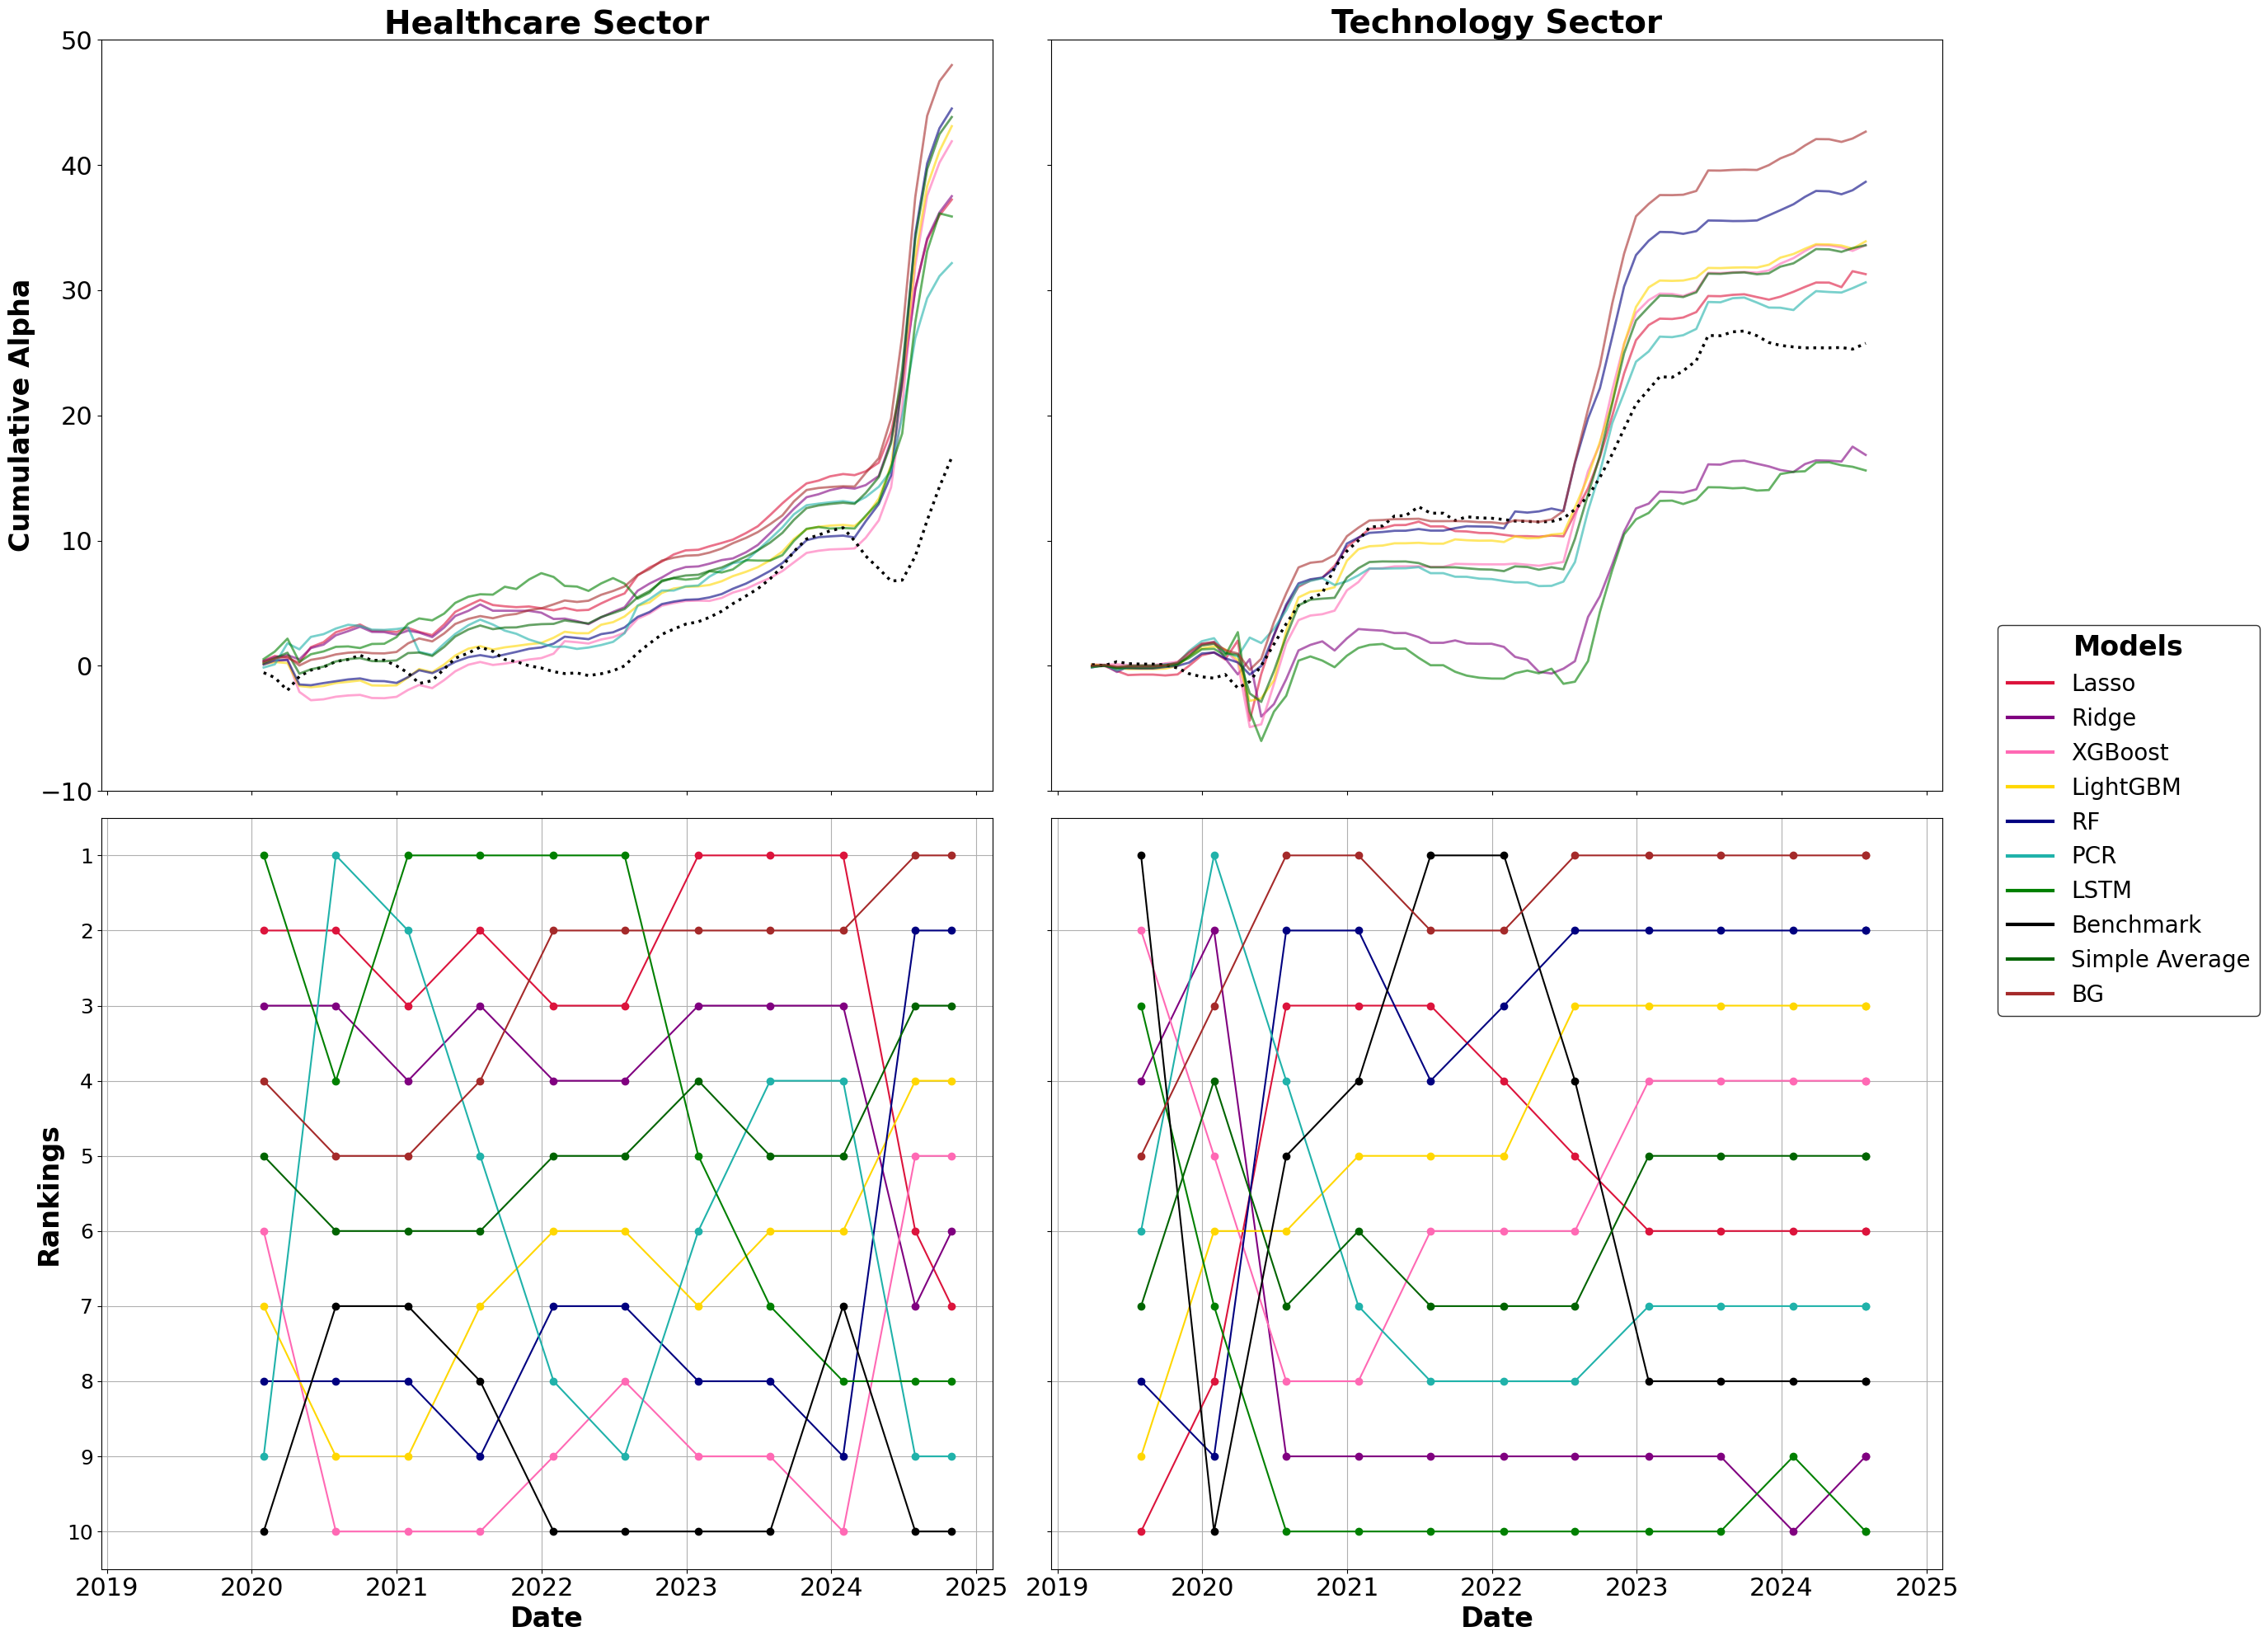

In [8]:
# Define color lists
color_list_healthcare = {'Ridge': 'purple', 'XGBoost': 'hotpink', 'PCR': 'lightseagreen', 'RF': 'navy', 'Lasso':'crimson', 
                  'LightGBM':'gold', 'LSTM':'green', 'Benchmark':'black',
                  'Simple Average':'darkgreen', 'BG':'brown'}
color_list_tech = {'Ridge': 'purple', 'XGBoost': 'hotpink', 'PCR': 'lightseagreen', 'RF': 'navy', 'Lasso':'crimson', 
                  'LightGBM':'gold', 'LSTM':'green', 'Benchmark':'black',
                  'Simple Average':'darkgreen', 'BG':'brown'}

# Call function for both sectors
plot_combined_subplot(all_results_healthcare_clean, all_results_tech_clean, plot_difference, 
                      outcome_var='rolling_alpha_5f', color_list1=color_list_healthcare, color_list2=color_list_tech)

# Wald-Statistic Computation to compare Forecast Accuracy

In [ ]:
import pandas as pd
tech_results = all_results_tech_clean.drop(columns=["Unnamed: 0","date"])
healthcare_results = all_results_healthcare_clean.drop(columns=["date"])
healthcare_results

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2
from itertools import combinations

def calculate_proportions(df, significance_level=0.05):
    # Model name mapping
    rename_mapping = {
        "lstm": "LSTM",
        "ridge": "Ridge",
        "lasso": "Lasso",
        "lgbm": "LightGBM",
        "xgboost": "XGBoost",
        "err_weighted": "BG",
        "simple_avg": "SA",
        "pca": "PCR",
        "rf": "RF",
        "benchmark_alpha": "Benchmark"
    }
    
    # Prepare the data - select only columns we need
    prediction_columns = list(rename_mapping.keys())
    df_long = (
        df[['rolling_alpha_5f'] + prediction_columns]
        .copy()
        .reset_index(drop=True)
        .assign(time=lambda x: x.index + 1)
        .melt(id_vars=['time', 'rolling_alpha_5f'], 
              var_name='model', 
              value_name='pred')
    )
    
    # Apply model name mapping
    df_long['model'] = df_long['model'].map(rename_mapping)
    
    # Process predictions and calculate absolute errors
    df_long['pred'] = df_long['pred'].clip(lower=0)
    df_long['err'] = (df_long['pred'] - df_long['rolling_alpha_5f']).abs()
    
    # Get unique model names and all possible pairs
    model_names = sorted(df_long['model'].unique())
    model_pairs = list(combinations(model_names, 2))
    
    # Initialize results
    final_df = pd.DataFrame(columns=["Model 1", "Model 2", "Outcome"])
    better_count = {model: 0 for model in model_names}
    total_comparisons = {model: 0 for model in model_names}
    
    def compute_wald_one_sided(errors1, errors2):
        diff = errors1 - errors2
        mean_diff = np.mean(diff)
        var_diff = np.var(diff, ddof=1) / len(diff)
        wald_stat = (mean_diff ** 2) / var_diff
        return wald_stat
    
    # Compare all model pairs
    for model1, model2 in model_pairs:
        model1_err = df_long[df_long['model'] == model1]['err'].values
        model2_err = df_long[df_long['model'] == model2]['err'].values
        
        wald_stat = compute_wald_one_sided(model1_err, model2_err)
        critical_value = chi2.ppf(1 - significance_level, df=1)
        
        if wald_stat > critical_value:
            if np.mean(model1_err) < np.mean(model2_err):
                better_count[model1] += 1
                outcome = "Model 1"
                print(f"{model1} is better than {model2}")
            else:
                better_count[model2] += 1
                outcome = "Model 2"
                print(f"{model1} is worse than {model2}")
        else:
            outcome = "Equivalent"
            print(f"Both {model1} and {model2} are equivalent")
        
        # Add to results dataframe
        final_df = pd.concat([
            final_df,
            pd.DataFrame({
                "Model 1": [model1],
                "Model 2": [model2],
                "Outcome": [outcome]
            })
        ], ignore_index=True)
        
        total_comparisons[model1] += 1
        total_comparisons[model2] += 1
    
    # Calculate proportions
    proportion_better = {
        model: better_count[model] / total_comparisons[model] 
        for model in model_names
    }
    
    return final_df, proportion_better

In [ ]:
comparison_results_healthcare, proportions_healthcare = calculate_proportions(healthcare_results)
comparison_results_tech, proportions_tech = calculate_proportions(tech_results)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
def plot_single_heatmap(df, ax, title, show_yticks=True):
    outcome_mapping = {
        "Model 1": -1,    # lightseagreen
        "Equivalent": 0,  # lightpink
        "Model 2": 1      # navy
    }
    
    models = sorted(set(df['Model 1'].unique()).union(set(df['Model 2'].unique())))
    comparison_matrix = pd.DataFrame(-2, index=models, columns=models, dtype=int)
    
    for _, row in df.iterrows():
        model1 = row['Model 1']
        model2 = row['Model 2']
        outcome = row['Outcome']
        comparison_matrix.loc[model2, model1] = outcome_mapping[outcome]
    
    mask = np.triu(np.ones_like(comparison_matrix, dtype=bool), k=1)
    cmap = ListedColormap(["navy", "lightpink", "lightseagreen", "#000000"])
    bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
    norm = BoundaryNorm(bounds, cmap.N)
    np.fill_diagonal(comparison_matrix.values, 2)
    
    sns.heatmap(
        comparison_matrix, 
        cmap=cmap, 
        norm=norm, 
        mask=mask, 
        cbar=False,
        linewidths=0.5, 
        linecolor="black", 
        ax=ax,
        square=True
    )
    
    ax.set_title(title, pad=20, fontsize = 35, fontweight = 'bold')
    ax.tick_params(
        axis='both',          # Both x and y axes
        which='both',         # Both major and minor ticks
        length=8,            # Tick length in points (default is 4)
        width=1,             # Tick width in points
        colors='black'       # Tick color
    )
    for i in range(comparison_matrix.shape[0]):
        for j in range(comparison_matrix.shape[1]):
            if i >= j:
                rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="black", linewidth=1)
                ax.add_patch(rect)
            else:
                rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="white", linewidth=1)
                ax.add_patch(rect)
    
    # Y-axis handling
    if show_yticks:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right", fontsize=25)
        ax.set_ylabel("Model 2", fontsize=30, fontweight="bold")
    else:
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.set_ylabel("")
    
    # X-axis (same for both)
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, fontsize=25)
    ax.set_xlabel("Model 1", fontsize=30, fontweight="bold")

def plot_side_by_side_heatmaps(healthcare_df, tech_df):
    # Create figure with 2 subplots and space for legend below
    fig = plt.figure(figsize=(32, 14))
    gs = fig.add_gridspec(2, 2, height_ratios=[12, 1], width_ratios=[1, 1], hspace=-0.2, wspace=-0.1)
    
    ax1 = fig.add_subplot(gs[0, 0])  # Healthcare heatmap (left)
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)  # Tech heatmap (shares y-axis)
    legend_ax = fig.add_subplot(gs[1, :])  # Common legend area
    
    # Plot both heatmaps
    plot_single_heatmap(healthcare_df, ax1, "Healthcare Sector", show_yticks=True)
    plot_single_heatmap(tech_df, ax2, "Technology Sector", show_yticks=False)
    
    # Create common legend
    legend_patches = [
        mpatches.Patch(color="navy", label="Model 1 Better"),
        mpatches.Patch(color="lightpink", label="Forecast Equivalence"),
        mpatches.Patch(color="lightseagreen", label="Model 2 Better"),
        mpatches.Patch(color="#000000", label="NA")
    ]
    
    legend =legend_ax.legend(
        handles=legend_patches,
        loc='center',
        bbox_to_anchor=(0.5, -3.5),
        ncol=4,
        fontsize=25,
        title="Categories",
        title_fontsize=30,
        frameon = True,
        edgecolor='black',
        framealpha=1
    )
    legend.get_frame().set_linewidth(2)
    legend.get_title().set_fontweight('bold')
    # Hide the legend axis
    legend_ax.axis('off')
    legend.set_visible(True)
    plt.tight_layout()
    plt.show()

# Usage
plot_side_by_side_heatmaps(comparison_results_healthcare, comparison_results_tech)